### STOMP (Simple (or Streaming) Text Oriented Messaging Protocol)

Nell'ambito dei **MOM** (*Message Oriented Middleware*), si è visto come essi fungano sostanzialmente da **intermediari** (*message broker*) tra vari client. I middleware (broker) MOM usano diversi protocolli, tra cui appunto ***STOMP***:

- Semplice protocollo basato su **testo**
- Progettato per lavorare con **middleware orientati ai messaggi** (MOM)
- Fornisce un formato wire-level che consente ai client STOMP di parlare con *qualsiasi broker di messaggi che supporti il protocollo*
- Protocollo **FRAME based** che assume l’utilizzo di un 2-way streaming network protocol (ad esempio TCP)
- Client e Server comunicano attraverso dei **STOMP Frame** inviati attraverso lo stream

Un frame STOMP è così fatto:

```text
COMMAND
Header1:value1
Header2:value2

Body^@
```

Una connessione si crea con `conn = stomp.Connection(host_and_ports, ...)`.

> The first parameter to a `Connection` is `host_and_ports`. This is a **list of tuples**, each containing ip address (which could be an ipv6 address) and the port where the message broker is listening for stomp connections. *The general idea with the list is to try each address until a successful socket connection is established* (giving the ability to provide multiple brokers for failover).

Ogni tupla è quindi del tipo `(ip-address: str, port: int)`

In [ ]:
import stomp
help(stomp.Connection.connect)
help(stomp.Connection.send) # invio di messaggi
help(stomp.Connection.set_listener)
help(stomp.Connection.subscribe)

Nel sender, supponendo di usare come broker [ActiveMQ](https://activemq.apache.org/) il flow tipico è:

In [ ]:
# Sender (client)

import stomp


conn = stomp.Connection([('127.0.0.1', 61613)]) # porta di default per ActiveMQ

conn.connect(wait=True)

msg = "Hello World!"
conn.send("/queue/test", msg.encode("utf-8"))

A questo punto, accedendo a `localhost:8181` nel browser (Sezione *Queues*) è possibile vedere questo:

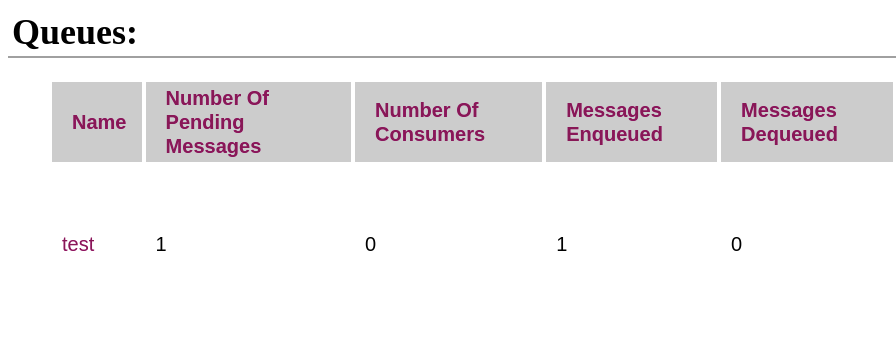

In [ ]:
# Receiver
import stomp
import time

# Definiamo una classe Listener, che eredita da
# stomp.ConnectionListener e sovrascriviamo il
# metodo on_message (è quello che effettivamente
# "intercetta" il messaggio (frame)
###############################################
class testListener(stomp.ConnectionListener):
    def on_message(self, frame):
        print(f"Ricevuto: {frame.body}")
###############################################


conn = stomp.Connection([('localhost', 61613)])

# Questa è l'aggiunta fondamentale nel
# receiver, cioè gli si fornisce un
# listener
######################################
conn.set_listener('', testListener())
######################################

conn.connect(wait=True)

conn.subscribe(destination="/queue/test", id=1)

# Questo è necessario perché la
# libreria STOMP con `connect()`
# crea un nuovo thread (L) in 
# background in ascolto sulla 
# rete e usiamo il while per 
# tenere in vita il mainThread
# e di conseguenza anche L 
################################
while True:
    time.sleep(1)
################################

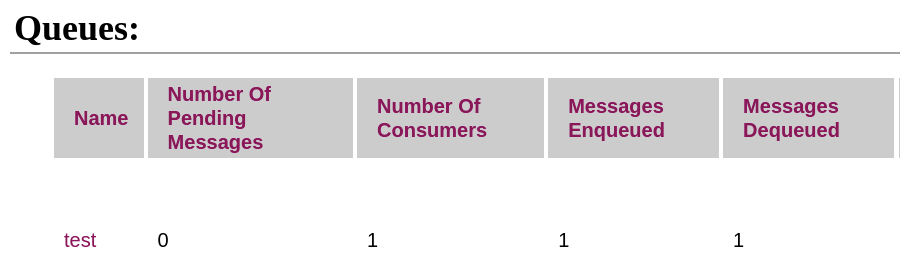

**Nota fondamentale:** ActiveMQ ha una feature abilitata di default chiamata **auto-creations of destinations** (`autoCreateQueues=True`), per cui sia la send che la subsribe *creano la coda on-demand* se non esiste ancora. Attenzione però, se il sender manda prima che nessuno sia in ascolto, il comportamento dipende dal tipo di destinazione:

| Tipo | Comportamento |
|---|---|
| **Queue** (`/queue/`) | Il messaggio viene **persistito** e consegnato quando arriva un consumer |
| **Topic** (`/topic/`) | Il messaggio viene **perso** se non c'è nessun subscriber attivo in quel momento |


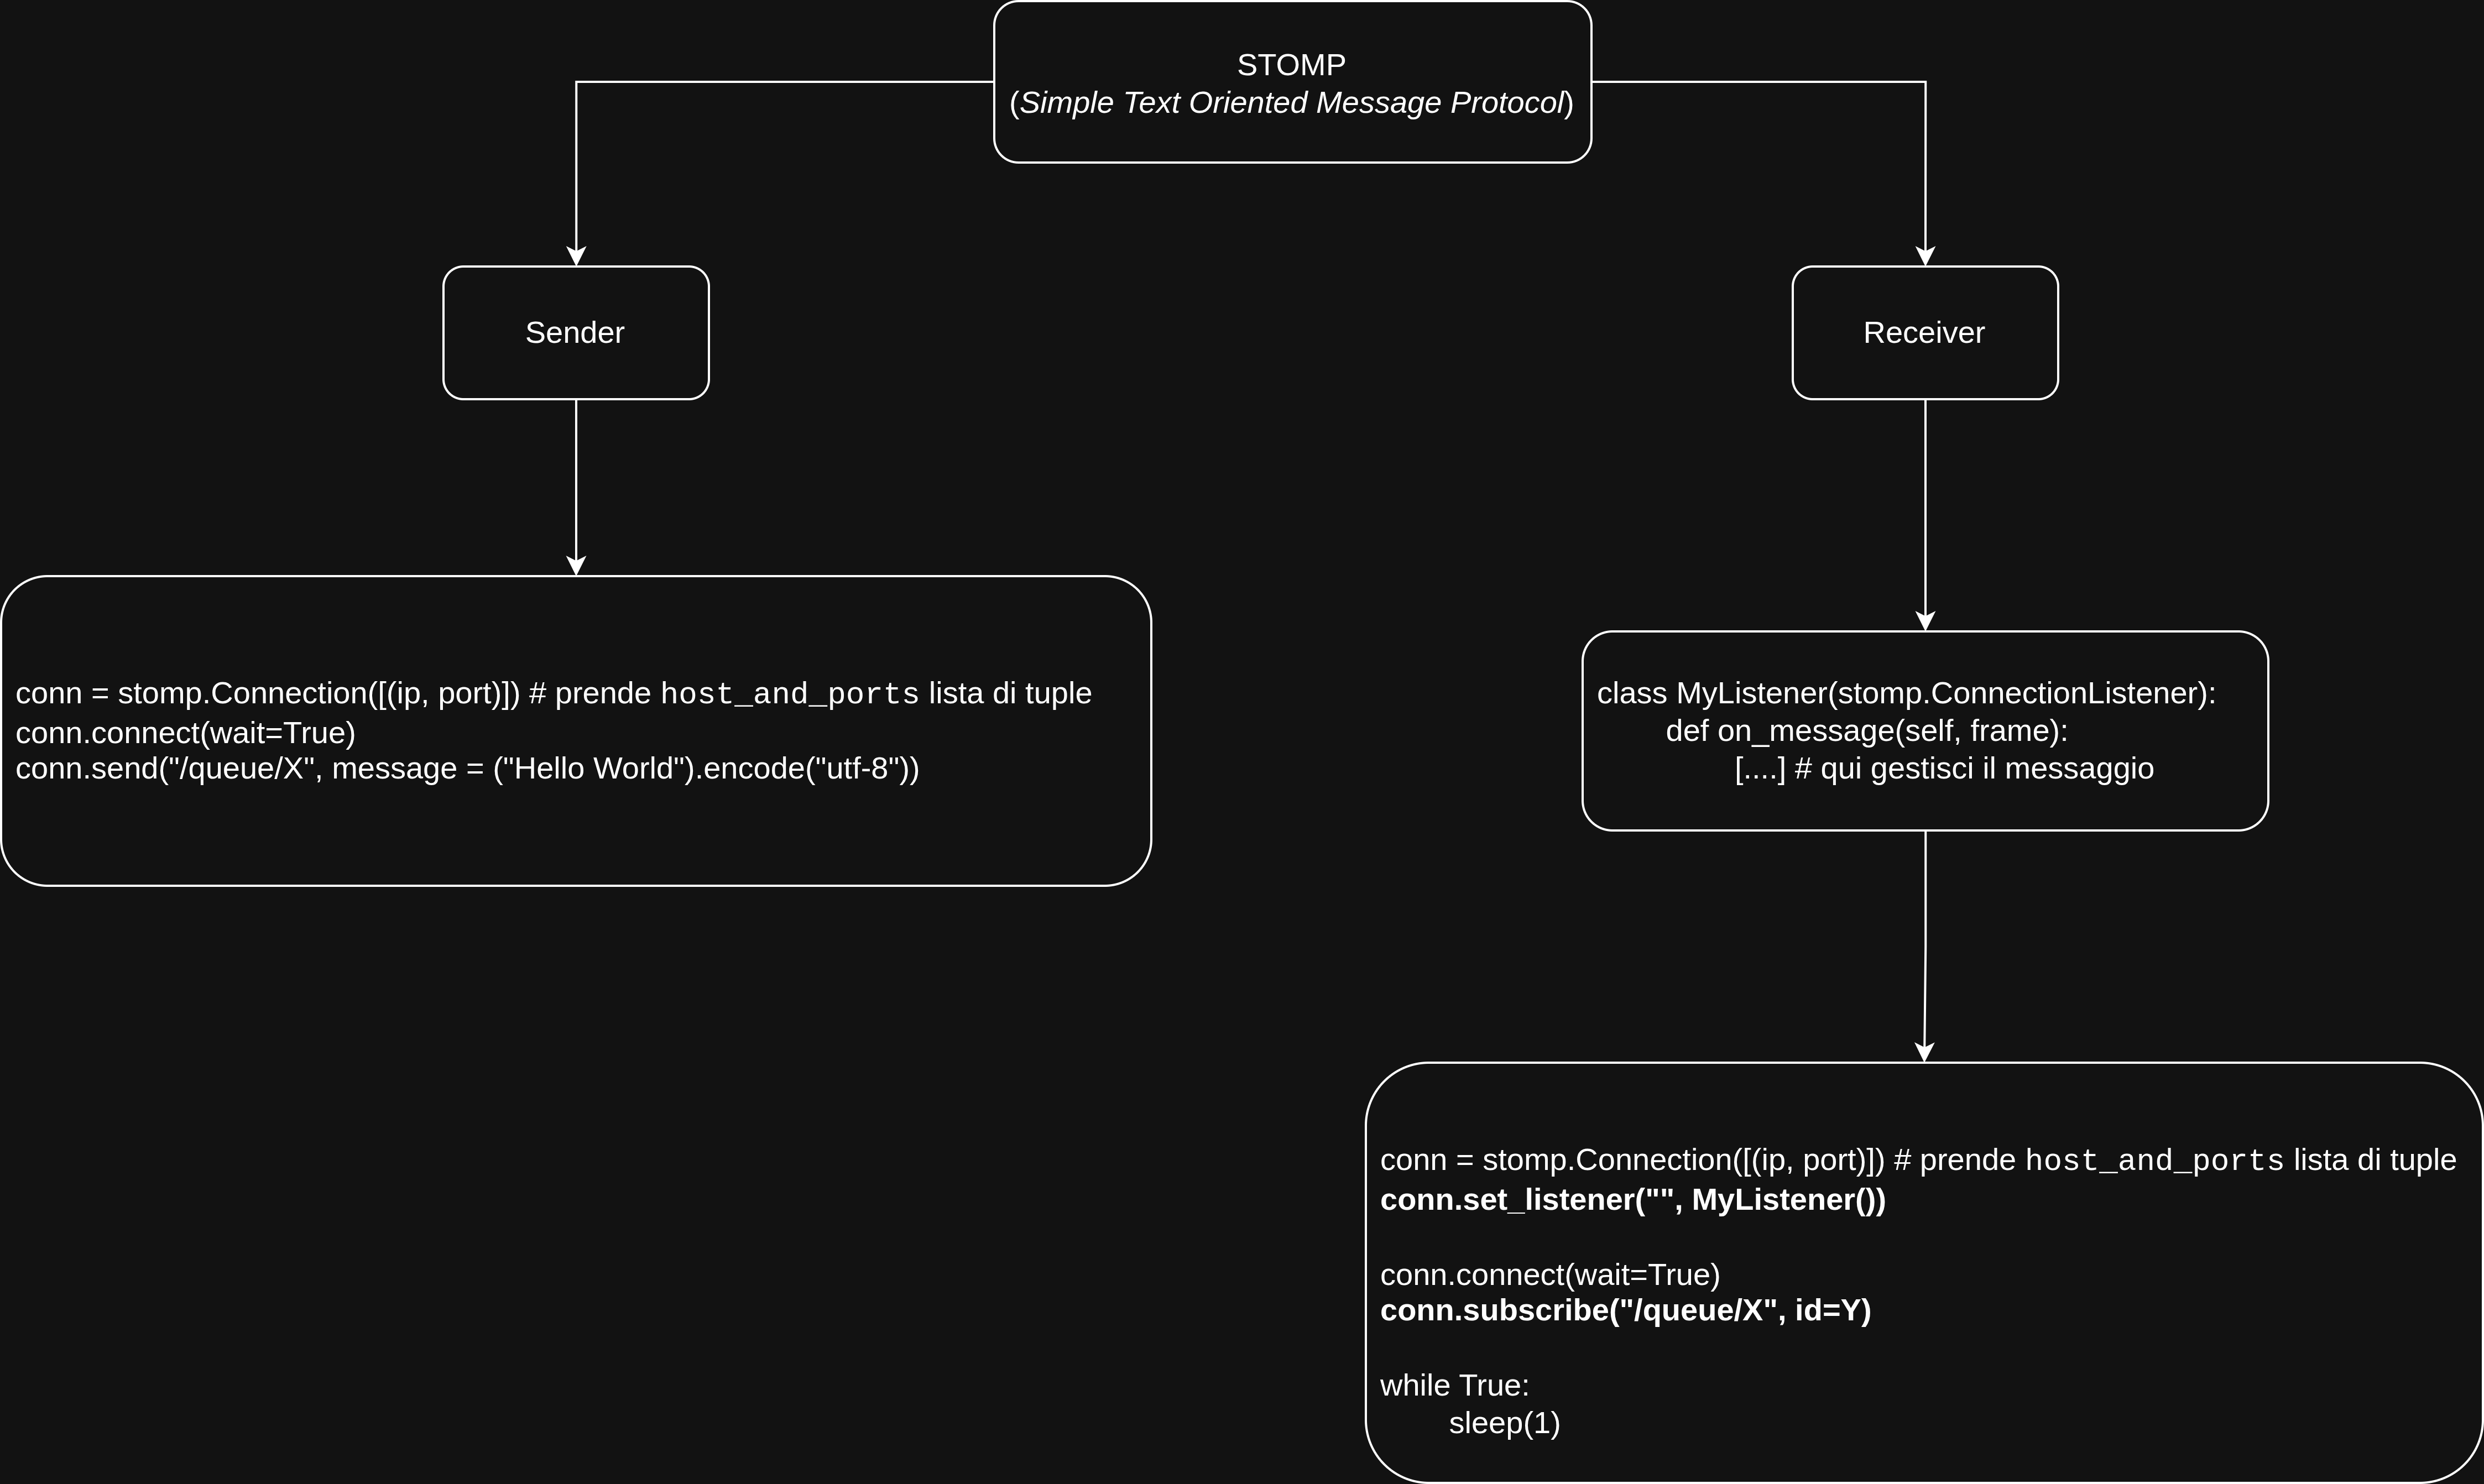

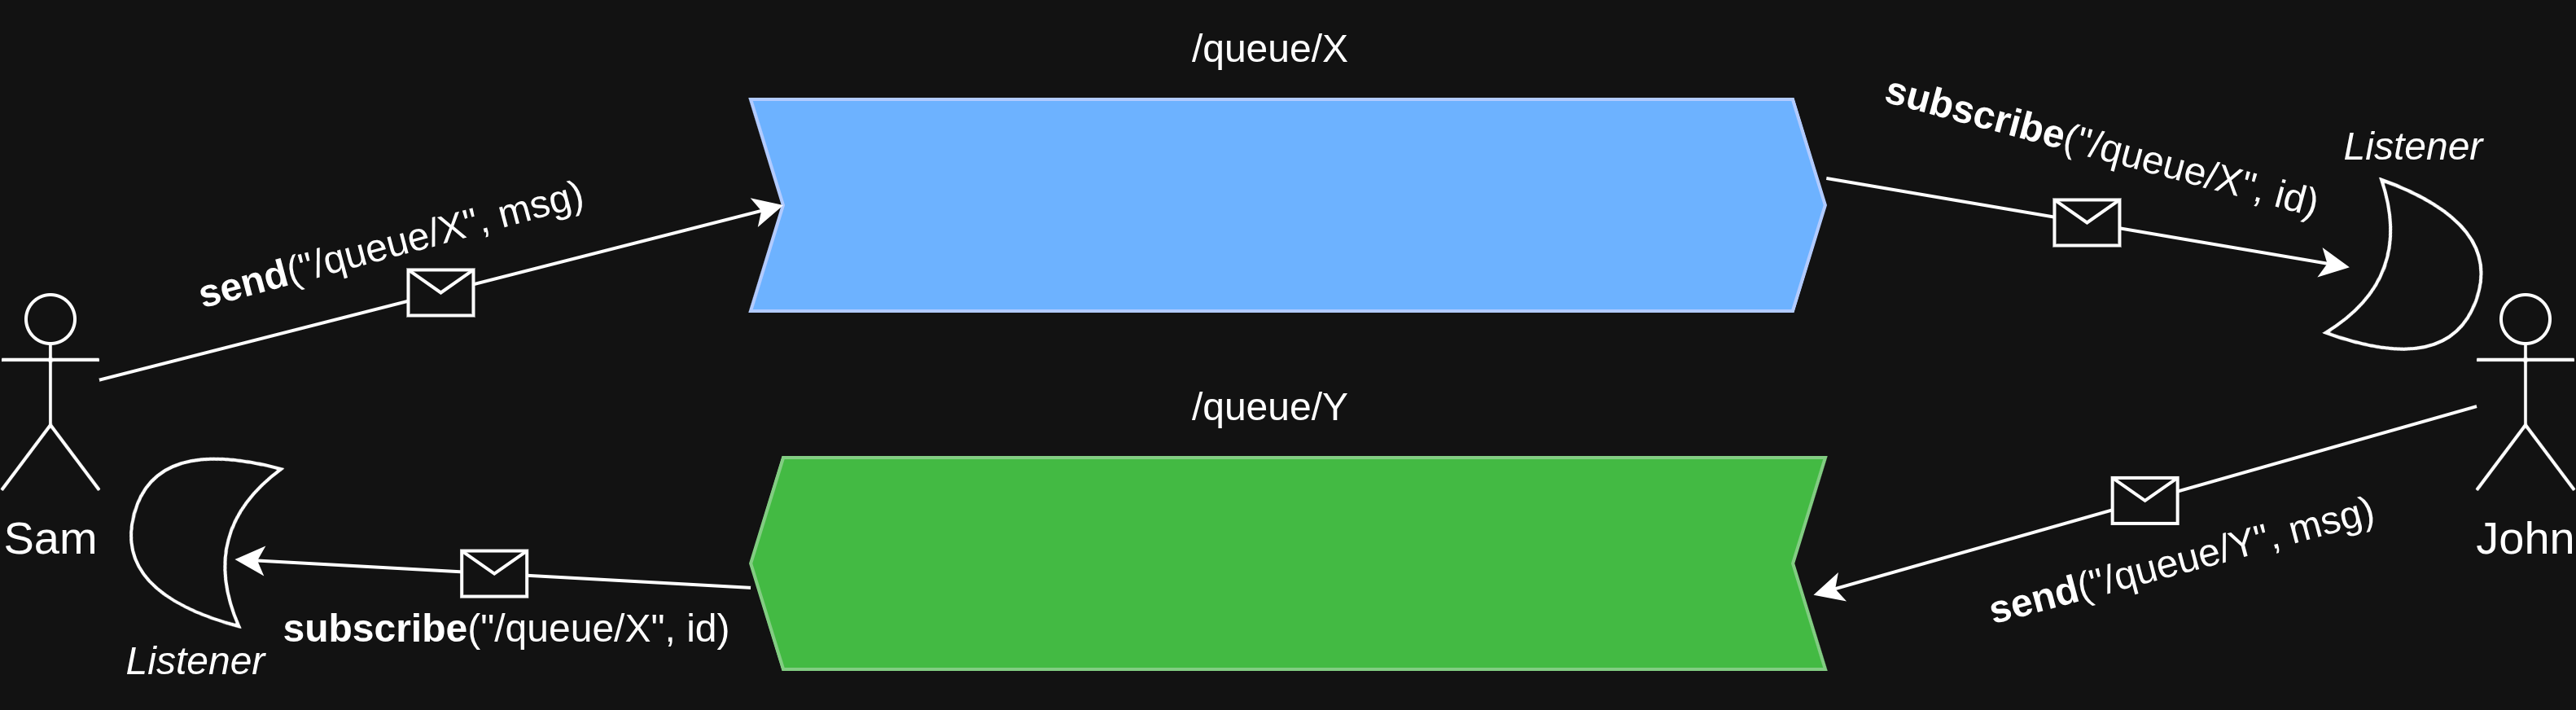